# 02 - EDA

## Objective

After completing the data audit, this notebook explores the dataset in greater depth to understand the behavior, usefulness, and business meaning of each feature.

The analysis will:

- examine numerical and categorical feature distributions;
- compare feature behavior across churn classes;
- identify potentially useful, redundant, weak, or suspicious features;
- investigate relationships between features and the target;
- detect patterns that may influence preprocessing and modeling decisions;
- document business observations and modeling implications.

No final transformations will be applied in this notebook. The conclusions from the EDA will guide the preprocessing stage, where features will be converted, encoded, scaled, removed, or otherwise transformed as required.

## Load audited data

The dataset is loaded for exploratory analysis after completing the initial data audit.

The previous audit identified the main data-quality issues, including invalid blank values in `TotalCharges`, the unique identifier `customerID`, target imbalance, and potential leakage risks.

This notebook will use the audited structure of the dataset to investigate feature distributions, feature-target relationships, and business patterns. Final preprocessing transformations will not be applied at this stage.

In [20]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [21]:
PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_PATH = DATA_DIR / "raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at {RAW_DATA_PATH.resolve()}")
dataset = pd.read_csv(RAW_DATA_PATH)

In [22]:
dataset.head(8)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No


### Validation

The dataset was loaded successfully with [number] rows and [number] columns.

The expected identifier, numerical, categorical, and target columns are present. The dataset is ready for exploratory analysis based on the findings documented in the data-audit notebook.

In [23]:
print(f'Columns from dataset: {dataset.columns.tolist()}\n'
      f'Len of columns {len(dataset.columns.tolist())}')

Columns from dataset: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
Len of columns 21


## Target Balance

This section examines whether the `Churn` target classes are balanced.

The result will guide later decisions about train-test splitting, model training, class imbalance techniques, and evaluation metrics.

In [24]:
target_counts = dataset["Churn"].value_counts(dropna=False)
percentage_no = (target_counts["No"] / (target_counts["No"] + target_counts["Yes"]))*100
percentage_yes = (target_counts["Yes"] / (target_counts["No"] + target_counts["Yes"]))*100
imbalance_ratio = target_counts["No"] / target_counts["Yes"]

print(target_counts)
print("-"*50)
print(f'Percentage for class No: {percentage_no:.2f}%')
print(f'Percentage for class Yes: {percentage_yes:.2f}%')
print("-"*50)
print(f'Imbalance ratio: {imbalance_ratio:.2f}')

Churn
No     5174
Yes    1869
Name: count, dtype: int64
--------------------------------------------------
Percentage for class No: 73.46%
Percentage for class Yes: 26.54%
--------------------------------------------------
Imbalance ratio: 2.77


### Interpretation

The target variable is moderately imbalanced.

The `No` class represents 73.46% of the observations, while the `Yes` class represents 26.54%. There are approximately 2.77 non-churn customers for every churn customer.

Because of this imbalance, accuracy alone may produce a misleading evaluation. The train-test split should preserve the class proportions using stratification, and the modeling stage should also evaluate recall, precision, F1-score, balanced accuracy, and PR-AUC for the churn class.

## Numerical feature analysis

In this section, I will analyze the numerical distributions and verify whether the values are valid and reasonable. I also need to convert `TotalCharges` to a numeric type before analyzing it.

In [25]:
dataset["TotalCharges"] = pd.to_numeric(dataset["TotalCharges"],errors='coerce')

In [26]:
print(f'Data type: {dataset["TotalCharges"].dtype}')
print(f'Total Missing values: {dataset["TotalCharges"].isna().sum()}')

Data type: float64
Total Missing values: 11


In [27]:
dataset.loc[dataset["TotalCharges"].isna(),["customerID", "tenure", "MonthlyCharges", "TotalCharges","Churn"]]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [28]:
missing_index = dataset.index[dataset["TotalCharges"].isna()]
missing_index

Index([488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], dtype='int64')

### Interpretation

There are 11 missing values in `TotalCharges`.

During the data audit, all affected customers were found to have `tenure = 0`, suggesting that they are new customers who have not yet accumulated historical charges.

Two possible treatments are:

1. Remove the 11 affected rows.
2. Replace the missing `TotalCharges` values with `0`.

Because the missing values follow a meaningful business pattern rather than appearing to be random corruption, replacing them with `0` is the more appropriate option. Removing the rows would discard valid new customers and could slightly alter the dataset distribution.

In [29]:
dataset["TotalCharges"] = dataset["TotalCharges"].fillna(0)

In [30]:
dataset.loc[missing_index,["customerID", "tenure", "MonthlyCharges", "TotalCharges","Churn"]]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,0.0,No
753,3115-CZMZD,0,20.25,0.0,No
936,5709-LVOEQ,0,80.85,0.0,No
1082,4367-NUYAO,0,25.75,0.0,No
1340,1371-DWPAZ,0,56.05,0.0,No
3331,7644-OMVMY,0,19.85,0.0,No
3826,3213-VVOLG,0,25.35,0.0,No
4380,2520-SGTTA,0,20.00,0.0,No
5218,2923-ARZLG,0,19.70,0.0,No
6670,4075-WKNIU,0,73.35,0.0,No


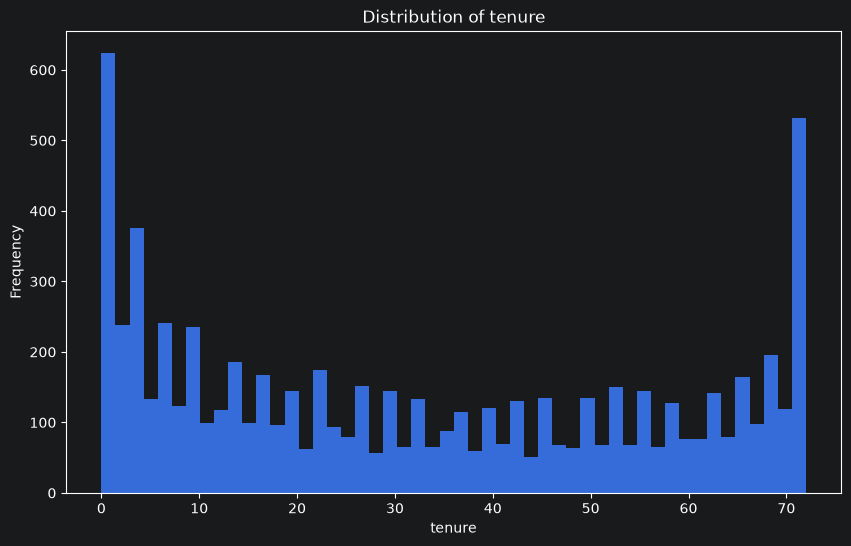

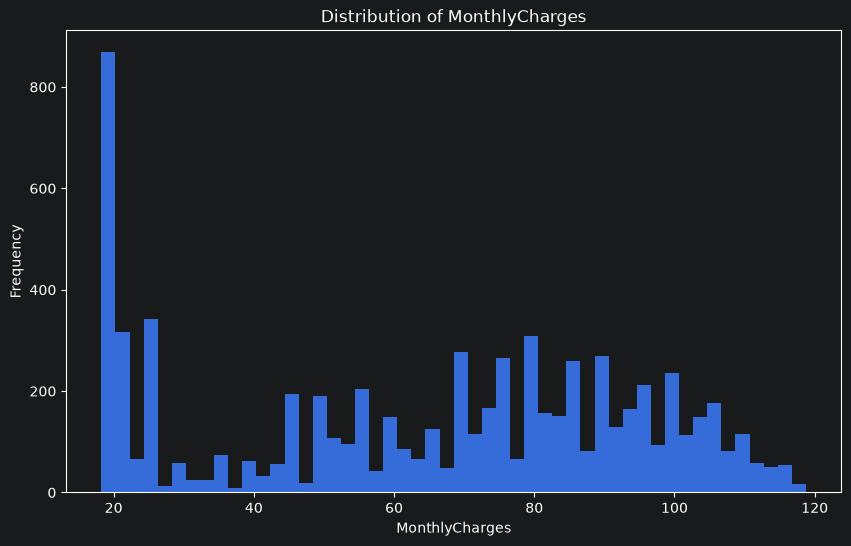

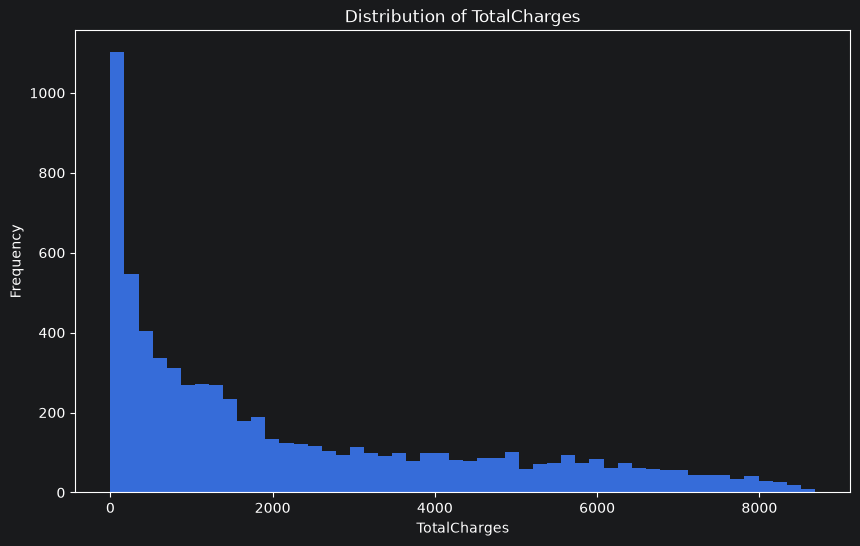

In [31]:
for feature_int in ["tenure", "MonthlyCharges", "TotalCharges"]:
    plt.figure(figsize=(10,6))
    plt.hist(dataset[feature_int],bins=50)
    plt.title(f"Distribution of {feature_int}")
    plt.xlabel(feature_int)
    plt.ylabel("Frequency")
    plt.show()

### Interpretation

No obvious outliers were observed in the numerical distributions.

The `TotalCharges` feature contained 11 missing values. During the audit, all affected records were associated with customers whose `tenure` was `0`, indicating that they had not yet accumulated historical charges.

These missing values were therefore replaced with `0` instead of removing the rows. This preserves valid information about new customers and avoids discarding potentially useful observations.

This decision does not imply that new customers are less likely to churn. It only reflects the business meaning of `TotalCharges` for customers with no completed tenure.

### `TotalCharges` Consistency Check

This analysis compares the recorded `TotalCharges` value with a simplified estimate calculated as:

`MonthlyCharges × tenure`

The estimated value assumes that the customer's current monthly charge remained constant throughout the entire customer relationship.

The difference is calculated as:

`Recorded TotalCharges − Estimated TotalCharges`

A difference close to zero indicates that the recorded total is similar to the simplified estimate. Positive or negative differences may reflect historical price changes, discounts, service modifications, partial billing periods, or other billing adjustments.

This comparison is used as a plausibility check and as a possible starting point for feature engineering. It is not an exact validation rule because `MonthlyCharges` represents the current monthly charge rather than the complete billing history.

In [32]:
TotalCharges_validation = dataset["MonthlyCharges"] * dataset["tenure"]
validation_totalcharges_df = pd.DataFrame({"validation_totalcharges":TotalCharges_validation, "totalcharges":dataset["TotalCharges"]})

In [33]:
difference_totalcharges = validation_totalcharges_df["totalcharges"] - validation_totalcharges_df["validation_totalcharges"]
validation_totalcharges_df["difference"] = difference_totalcharges

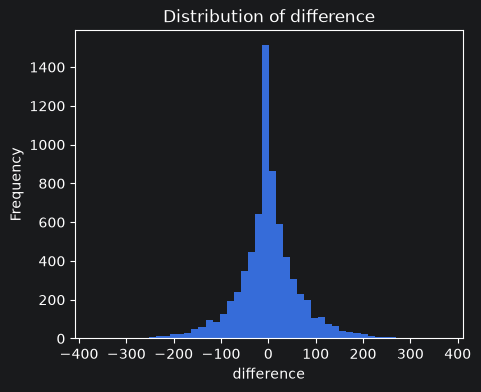

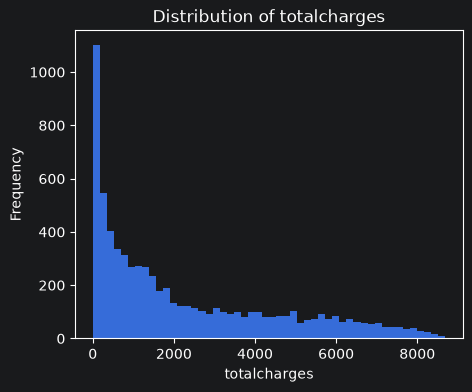

In [34]:
for feature_int in ["difference","totalcharges"]:
    plt.figure(figsize=(5,4))
    plt.hist(validation_totalcharges_df[feature_int],bins=50)
    plt.title(f"Distribution of {feature_int}")
    plt.xlabel(feature_int)
    plt.ylabel("Frequency")
    plt.show()

In [35]:
validation_totalcharges_df.describe()

,validation_totalcharges,totalcharges,difference
count,7043.000000,7043.000000,7043.000000
mean,2279.581350,2279.734304,0.152953
std,2264.729447,2266.794470,67.202778
min,0.000000,0.000000,-370.850000
25%,394.000000,398.550000,-28.600000
50%,1393.600000,1394.550000,0.000000
75%,3786.100000,3786.600000,28.500000
max,8550.000000,8684.800000,373.250000


### Interpretation

The estimated and recorded `TotalCharges` values are generally consistent.

The mean difference is approximately `0.15`, while the median difference is `0`. In addition, 50% of the observations have differences between approximately `-28.60` and `28.50`. This indicates that the simplified estimate is close to the recorded value for most customers.

However, some observations show larger differences, ranging from approximately `-370.85` to `373.25`. These differences are plausible because `MonthlyCharges` represents the current monthly charge and may not reflect the amount paid during every previous billing period.

Therefore, `MonthlyCharges × tenure` should be treated as an approximate consistency check rather than an exact reconstruction of `TotalCharges`.

The recorded `TotalCharges` feature should be retained. The derived difference may later be evaluated as a candidate engineered feature to determine whether historical billing variation is associated with churn.

## Categorical Feature Analysis

This section analyzes each categorical feature to understand its business meaning, category distribution, and relationship with customer churn.

The objective is to identify features that may provide useful predictive information, detect rare or suspicious categories, and determine which variables should be retained, transformed, grouped, or treated cautiously during preprocessing and modeling.

In [36]:
PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_PATH = DATA_DIR / "processed" / "column_audit.csv"
column_audit = pd.read_csv(PROCESSED_DATA_PATH)
if not PROCESSED_DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at {PROCESSED_DATA_PATH.resolve()}")
column_audit

,Unnamed: 0,column,dtype,unique_count,possible_role
0,0,customerID,str,7043,identifier
1,1,gender,str,2,binary categorical
2,2,SeniorCitizen,int64,2,binary categorical stored as integer
3,3,Partner,str,2,binary categorical
4,4,Dependents,str,2,binary categorical
5,5,tenure,int64,73,numeric
6,6,PhoneService,str,2,binary categorical
7,7,MultipleLines,str,3,multiclass categorical
8,8,InternetService,str,3,multiclass categorical
9,9,OnlineSecurity,str,3,multiclass categorical


In [38]:
not_numerical = column_audit.loc[column_audit["possible_role"] != "numeric"]

not_numerical

,Unnamed: 0,column,dtype,unique_count,possible_role
0,0,customerID,str,7043,identifier
1,1,gender,str,2,binary categorical
2,2,SeniorCitizen,int64,2,binary categorical stored as integer
3,3,Partner,str,2,binary categorical
4,4,Dependents,str,2,binary categorical
6,6,PhoneService,str,2,binary categorical
7,7,MultipleLines,str,3,multiclass categorical
8,8,InternetService,str,3,multiclass categorical
9,9,OnlineSecurity,str,3,multiclass categorical
10,10,OnlineBackup,str,3,multiclass categorical


### Feature: `[feature name]`

#### Meaning
What does the feature represent?

#### Categories
Which values exist, and how many customers belong to each category?

#### Analysis Question
Does the churn rate differ across the categories?

#### Result
Show the category counts and churn rate per category.

#### Interpretation
Describe the strongest differences.

#### Business Relevance
Explain why the pattern may matter to the company.

#### Modeling Implication
State whether the feature appears useful and how it may need to be encoded.

#### Limitation
Clarify that the relationship is associative, not necessarily causal.